In [2]:
import pandas as pd

filename = "../../data/processed/frogID5_database_prepared.csv"
frogID5_database_final = pd.read_csv(filename, sep=',', on_bad_lines='skip')

In [3]:
### preparing data

nsw_data = frogID5_database_final[frogID5_database_final['stateProvince'] == 'New South Wales']

user_counts = nsw_data['recordedBy'].dropna().value_counts().reset_index()
user_counts.columns = ['recordedBy', 'count']
unique_users = user_counts.sort_values(by='count', ascending=False).head(9)

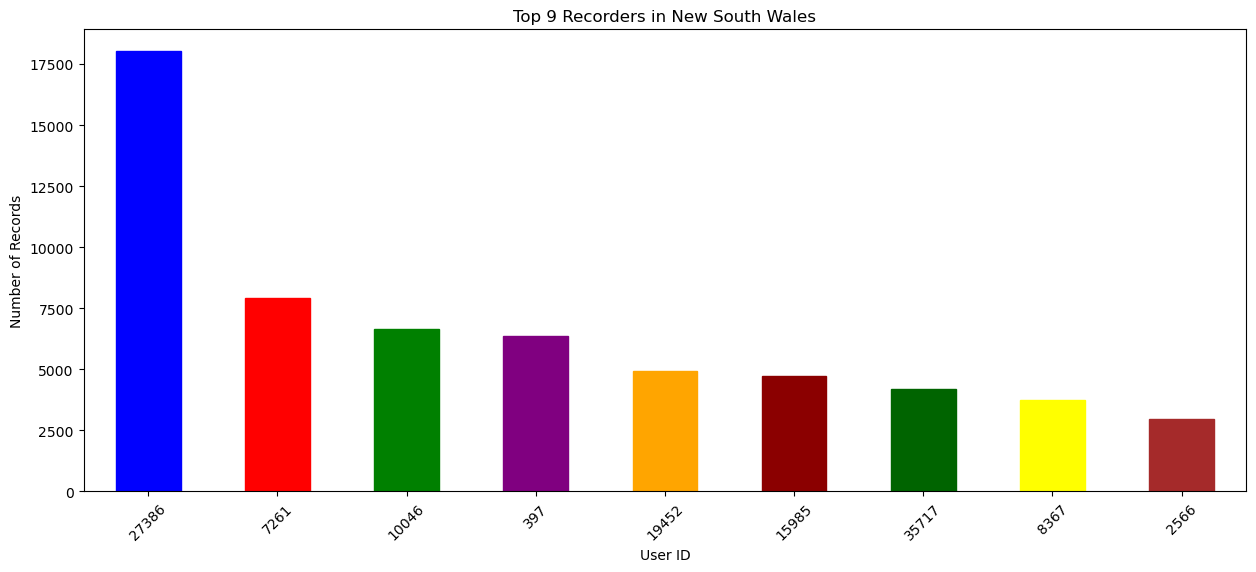

In [4]:
import matplotlib.pyplot as plt

# Bar chart
unique_users.plot(kind='bar', x='recordedBy', y='count', legend=False)
ax.set_title('Top 9 Recorders in New South Wales')
ax.set_xlabel('User ID')
ax.set_ylabel('Number of Records')
ax.tick_params(axis='x', rotation=45)

colors = ['blue', 'red', 'green', 'purple', 'orange', 'darkred', 'darkgreen', 'yellow', 'brown']
bars = ax.patches
for i in range(len(bars)):
    bars[i].set_color(colors[i])  


In [10]:
### showing general distribution of frogs in australia (different color for states)

import folium

sample_size = 1000

frog_in_states_map = folium.Map(location=[-33.8688, 151.2093], zoom_start=6)  
unique_users
# adding CircleMarkers for every stateProvince
for i in range(len(unique_users)):
    user_id = unique_users.iloc[i]['recordedBy']
    user_data = nsw_data[nsw_data['recordedBy'] == user_id]
    
    if len(user_data) >= sample_size:
        sample_data = user_data.sample(sample_size)
    else:
        sample_data = user_data
    
    for idx, row in sample_data.iterrows():
        folium.CircleMarker(
            location=[row['decimalLatitude'], row['decimalLongitude']],
            radius=2,
            color=colors[i], 
            fill=True,
            fill_color=colors[i],
            fill_opacity=1
        ).add_to(frog_in_states_map)

frog_in_states_map